In [2]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

RAW = Path("../data/raw")
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

print("Libraries ready ✓")

Libraries ready ✓


In [3]:
# Cell 2 — Load all datasets
wb  = pd.read_csv(RAW / "wb_pakistan_health_indicators.csv")
who = pd.read_csv(RAW / "who_pakistan_catastrophic_exp.csv")
hc  = pd.read_csv(RAW / "healthcare_dataset.csv")

print("World Bank:", wb.shape)
print(wb.head())
print("\nWHO:", who.shape)
print(who.head())

World Bank: (30, 8)
   year  oop_pct_current_health_exp  health_exp_pct_gdp  \
0  2024                         NaN                 NaN   
1  2023                   52.932320            2.519883   
2  2022                   47.365227            2.903548   
3  2021                   50.675240            2.990158   
4  2020                   55.239006            2.952730   

   private_health_exp_pct  govt_health_exp_pct_gdp  total_population  \
0                     NaN                      NaN         251269164   
1               54.611496                 0.900087         247504495   
2               48.683113                 1.107710         243700667   
3               52.781277                 1.111546         239477801   
4               58.476280                 1.039756         235001746   

   gdp_per_capita_usd  poverty_headcount_pct  
0         1478.772780                    NaN  
1         1360.324178                    NaN  
2         1538.322813                    NaN  
3   

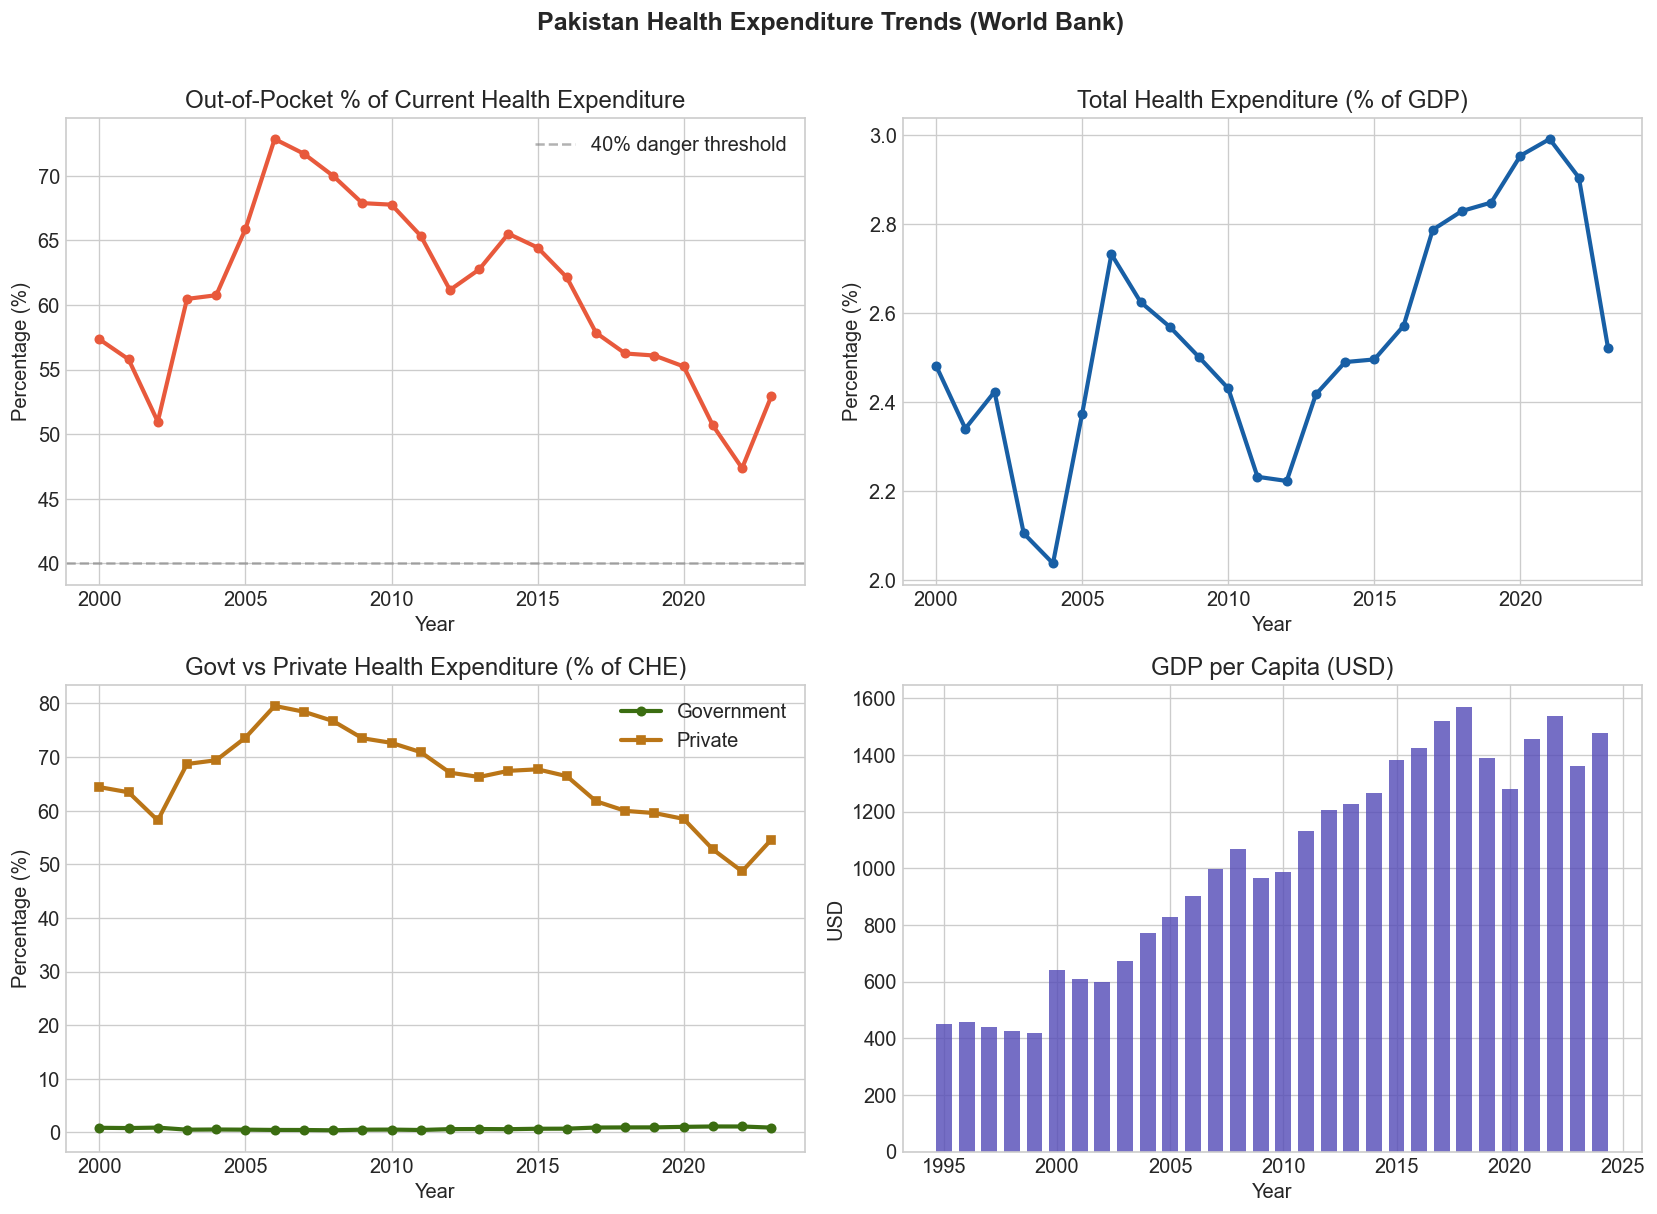

Saved: reports/figures/01_wb_health_trends.png ✓


In [4]:
# Cell 3 — WB: OOP trend over years
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Pakistan Health Expenditure Trends (World Bank)", 
             fontsize=15, fontweight='bold', y=1.01)

wb_sorted = wb.sort_values("year")

# Plot 1: OOP %
ax = axes[0,0]
ax.plot(wb_sorted["year"], wb_sorted["oop_pct_current_health_exp"], 
        color="#E8593C", linewidth=2.5, marker='o', markersize=5)
ax.set_title("Out-of-Pocket % of Current Health Expenditure")
ax.set_xlabel("Year"); ax.set_ylabel("Percentage (%)")
ax.axhline(y=40, color='gray', linestyle='--', alpha=0.6, label="40% danger threshold")
ax.legend()

# Plot 2: Health exp % GDP
ax = axes[0,1]
ax.plot(wb_sorted["year"], wb_sorted["health_exp_pct_gdp"], 
        color="#185FA5", linewidth=2.5, marker='o', markersize=5)
ax.set_title("Total Health Expenditure (% of GDP)")
ax.set_xlabel("Year"); ax.set_ylabel("Percentage (%)")

# Plot 3: Govt vs Private
ax = axes[1,0]
ax.plot(wb_sorted["year"], wb_sorted["govt_health_exp_pct_gdp"], 
        color="#3B6D11", linewidth=2.5, marker='o', markersize=5, label="Government")
ax.plot(wb_sorted["year"], wb_sorted["private_health_exp_pct"], 
        color="#BA7517", linewidth=2.5, marker='s', markersize=5, label="Private")
ax.set_title("Govt vs Private Health Expenditure (% of CHE)")
ax.set_xlabel("Year"); ax.set_ylabel("Percentage (%)")
ax.legend()

# Plot 4: GDP per capita
ax = axes[1,1]
ax.bar(wb_sorted["year"], wb_sorted["gdp_per_capita_usd"], 
       color="#534AB7", alpha=0.8, width=0.7)
ax.set_title("GDP per Capita (USD)")
ax.set_xlabel("Year"); ax.set_ylabel("USD")

plt.tight_layout()
plt.savefig(FIG / "01_wb_health_trends.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: reports/figures/01_wb_health_trends.png ✓")

In [5]:
# Cell 4 — WHO Catastrophic Expenditure
print("WHO Data:")
print(who.columns.tolist())
print(who)

WHO Data:
['year', 'catastrophic_10pct', 'catastrophic_25pct']
     year  catastrophic_10pct  catastrophic_25pct
0    2001                3.56                0.09
1    2001                3.56                0.08
2    2001                3.56                0.06
3    2001                5.97                0.09
4    2001                5.97                0.08
..    ...                 ...                 ...
286  2018                6.46                0.82
287  2018                6.46                1.02
288  2018                5.07                1.13
289  2018                5.07                0.82
290  2018                5.07                1.02

[291 rows x 3 columns]


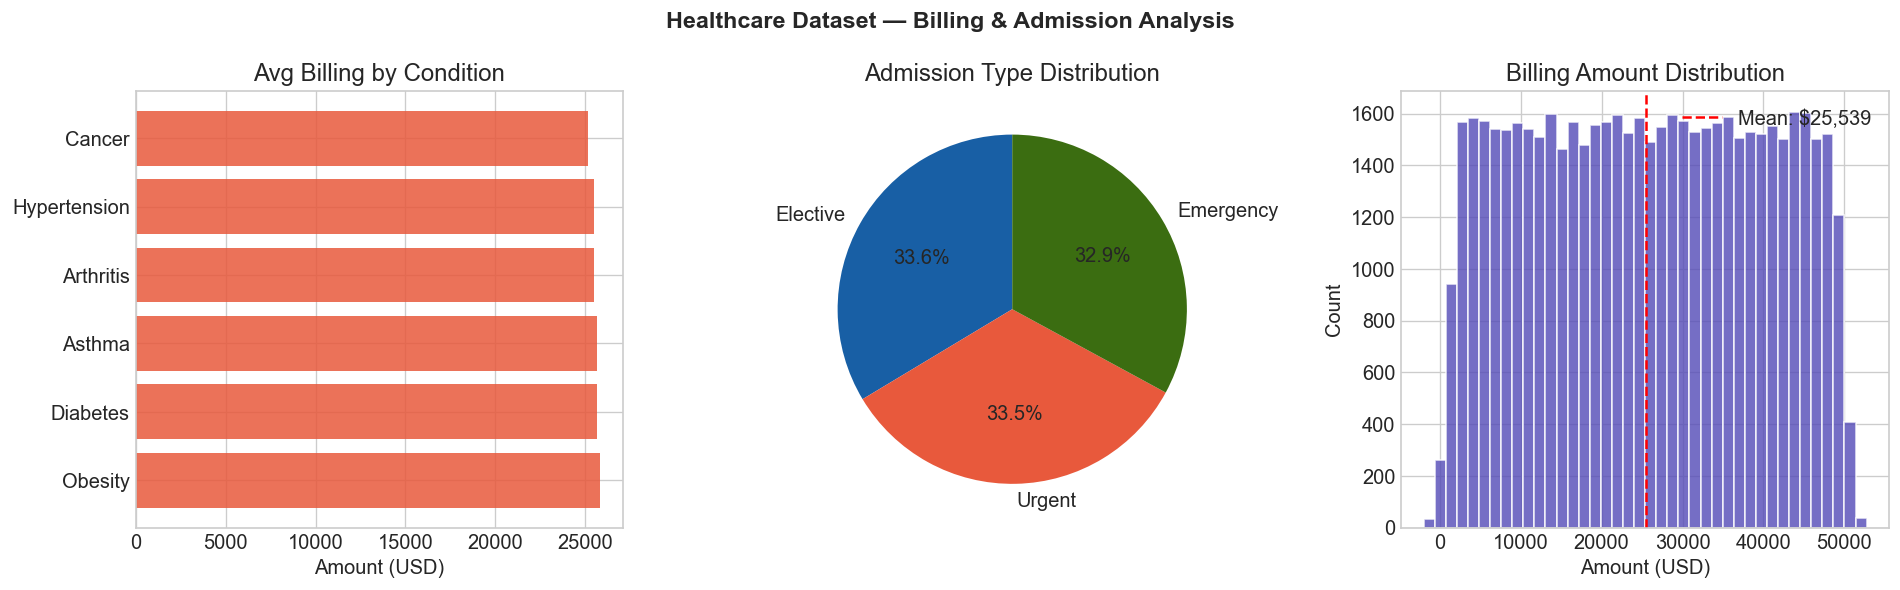

Saved: reports/figures/02_billing_analysis.png ✓


In [6]:
# Cell 5 — Healthcare dataset: Billing Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Healthcare Dataset — Billing & Admission Analysis", 
             fontsize=14, fontweight='bold')

# Billing by Medical Condition
avg_billing = hc.groupby("Medical Condition")["Billing Amount"].mean().sort_values(ascending=False)
axes[0].barh(avg_billing.index, avg_billing.values, color="#E8593C", alpha=0.85)
axes[0].set_title("Avg Billing by Condition")
axes[0].set_xlabel("Amount (USD)")

# Admission Type
admission_counts = hc["Admission Type"].value_counts()
colors = ["#185FA5", "#E8593C", "#3B6D11"]
axes[1].pie(admission_counts.values, labels=admission_counts.index, 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title("Admission Type Distribution")

# Billing Distribution
axes[2].hist(hc["Billing Amount"], bins=40, color="#534AB7", alpha=0.8, edgecolor='white')
axes[2].set_title("Billing Amount Distribution")
axes[2].set_xlabel("Amount (USD)")
axes[2].set_ylabel("Count")
axes[2].axvline(hc["Billing Amount"].mean(), color='red', 
                linestyle='--', label=f'Mean: ${hc["Billing Amount"].mean():,.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG / "02_billing_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: reports/figures/02_billing_analysis.png ✓")

In [7]:
# Cell 6 — Key Statistics (paper mein jayenge)
print("=" * 55)
print("KEY STATISTICS FOR PAPER")
print("=" * 55)

latest = wb_sorted.dropna(subset=["oop_pct_current_health_exp"]).iloc[0]
print(f"\nLatest OOP % (Year {int(latest['year'])}):"
      f"  {latest['oop_pct_current_health_exp']:.1f}%")
print(f"WHO danger threshold:             40%")
print(f"Pakistan exceeds threshold by:    "
      f"{latest['oop_pct_current_health_exp']-40:.1f}%")

print(f"\nHealthcare Dataset:")
print(f"  Total records:    {len(hc):,}")
print(f"  Mean billing:     ${hc['Billing Amount'].mean():,.0f}")
print(f"  Median billing:   ${hc['Billing Amount'].median():,.0f}")
print(f"  Max billing:      ${hc['Billing Amount'].max():,.0f}")

print(f"\nTop 3 high-cost conditions:")
print(avg_billing.head(3).to_string())
print("=" * 55)

KEY STATISTICS FOR PAPER

Latest OOP % (Year 2000):  57.3%
WHO danger threshold:             40%
Pakistan exceeds threshold by:    17.3%

Healthcare Dataset:
  Total records:    55,500
  Mean billing:     $25,539
  Median billing:   $25,538
  Max billing:      $52,764

Top 3 high-cost conditions:
Medical Condition
Obesity     25805.971259
Diabetes    25638.405577
Asthma      25635.249359


In [8]:
# Cell 7 — WHO data clean karo (duplicates handle)
who_clean = who.groupby("year")[["catastrophic_10pct", "catastrophic_25pct"]].mean().reset_index()
who_clean = who_clean.sort_values("year")

print("WHO cleaned shape:", who_clean.shape)
print(who_clean)

WHO cleaned shape: (8, 3)
   year  catastrophic_10pct  catastrophic_25pct
0  2001            6.026667            0.076667
1  2004            3.559091            0.073333
2  2007            2.778182            0.036667
3  2010            3.220000            0.330000
4  2011            3.976667            0.456667
5  2013            6.969231            0.586667
6  2015            5.393077            0.463333
7  2018            6.791538            0.990000


In [9]:
# Cell 8 — WHO + WB merge karke master dataset banao
wb_sorted = wb.sort_values("year").dropna(subset=["oop_pct_current_health_exp"])

master = pd.merge(wb_sorted, who_clean, on="year", how="left")
master = master.sort_values("year").reset_index(drop=True)

print("Master dataset shape:", master.shape)
print(master.columns.tolist())
master.to_csv(Path("../data/raw/master_pakistan_health.csv"), index=False)
print("\nSaved: master_pakistan_health.csv ✓")
print(master[["year","oop_pct_current_health_exp","catastrophic_10pct","gdp_per_capita_usd"]].to_string())

Master dataset shape: (24, 10)
['year', 'oop_pct_current_health_exp', 'health_exp_pct_gdp', 'private_health_exp_pct', 'govt_health_exp_pct_gdp', 'total_population', 'gdp_per_capita_usd', 'poverty_headcount_pct', 'catastrophic_10pct', 'catastrophic_25pct']

Saved: master_pakistan_health.csv ✓
    year  oop_pct_current_health_exp  catastrophic_10pct  gdp_per_capita_usd
0   2000                   57.342270                 NaN          642.338346
1   2001                   55.793098            6.026667          609.939507
2   2002                   50.964855                 NaN          599.937346
3   2003                   60.464455                 NaN          672.441787
4   2004                   60.750313            3.559091          771.902247
5   2005                   65.867172                 NaN          827.619861
6   2006                   72.837440                 NaN          900.873565
7   2007                   71.698746            2.778182          998.090114
8   2008      

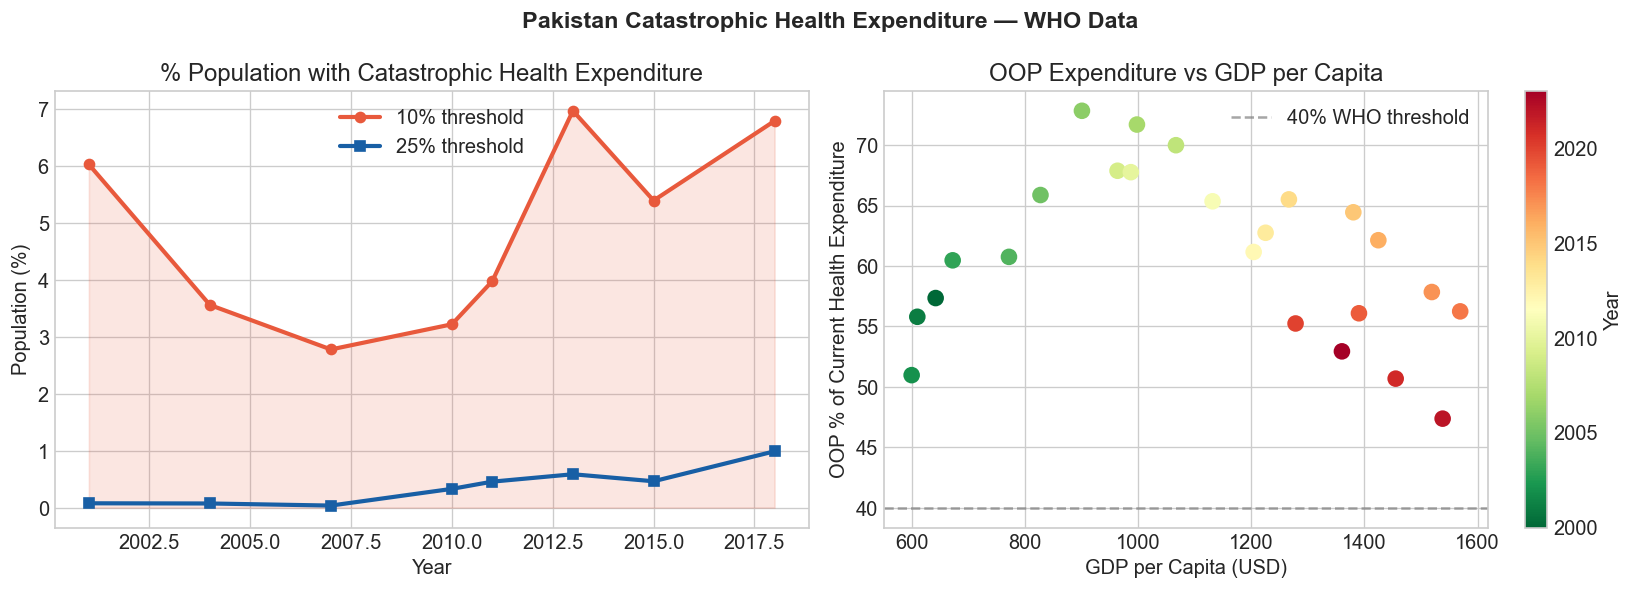

Saved: reports/figures/03_catastrophic_who_trends.png ✓


In [10]:
# Cell 9 — Catastrophic Expenditure Trend (paper ka main figure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pakistan Catastrophic Health Expenditure — WHO Data", 
             fontsize=14, fontweight='bold')

# WHO catastrophic trend
ax = axes[0]
ax.plot(who_clean["year"], who_clean["catastrophic_10pct"],
        color="#E8593C", linewidth=2.5, marker='o', markersize=6, label="10% threshold")
ax.plot(who_clean["year"], who_clean["catastrophic_25pct"],
        color="#185FA5", linewidth=2.5, marker='s', markersize=6, label="25% threshold")
ax.set_title("% Population with Catastrophic Health Expenditure")
ax.set_xlabel("Year")
ax.set_ylabel("Population (%)")
ax.legend()
ax.fill_between(who_clean["year"], who_clean["catastrophic_10pct"], 
                alpha=0.15, color="#E8593C")

# OOP vs GDP scatter
ax = axes[1]
merged_plot = master.dropna(subset=["oop_pct_current_health_exp","gdp_per_capita_usd"])
scatter = ax.scatter(merged_plot["gdp_per_capita_usd"], 
                     merged_plot["oop_pct_current_health_exp"],
                     c=merged_plot["year"], cmap="RdYlGn_r", 
                     s=80, zorder=5)
plt.colorbar(scatter, ax=ax, label="Year")
ax.set_title("OOP Expenditure vs GDP per Capita")
ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("OOP % of Current Health Expenditure")
ax.axhline(y=40, color='gray', linestyle='--', alpha=0.7, label="40% WHO threshold")
ax.legend()

plt.tight_layout()
plt.savefig(FIG / "03_catastrophic_who_trends.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: reports/figures/03_catastrophic_who_trends.png ✓")

In [11]:
# Cell 10 — Feature Engineering (ML ke liye prepare)
master["oop_above_40"]        = (master["oop_pct_current_health_exp"] > 40).astype(int)
master["oop_above_60"]        = (master["oop_pct_current_health_exp"] > 60).astype(int)
master["private_dominance"]   = master["private_health_exp_pct"] / (master["govt_health_exp_pct_gdp"] + 0.01)
master["health_gdp_ratio"]    = master["health_exp_pct_gdp"] / master["gdp_per_capita_usd"] * 1000
master["pop_millions"]        = master["total_population"] / 1_000_000
master["year_normalized"]     = (master["year"] - master["year"].min()) / (master["year"].max() - master["year"].min())

print("Features added:")
print(master[["year","oop_above_40","oop_above_60","private_dominance","health_gdp_ratio"]].head(10))

master.to_csv(Path("../data/raw/master_pakistan_health.csv"), index=False)
print("\nMaster dataset updated with features ✓")
print(f"Shape: {master.shape}")
print(f"\nTarget variable distribution:")
print(f"  OOP > 40% (high risk):  {master['oop_above_40'].sum()}/{len(master)} years ({master['oop_above_40'].mean()*100:.0f}%)")
print(f"  OOP > 60% (crisis):     {master['oop_above_60'].sum()}/{len(master)} years ({master['oop_above_60'].mean()*100:.0f}%)")

Features added:
   year  oop_above_40  oop_above_60  private_dominance  health_gdp_ratio
0  2000             1             0          73.590265          3.862129
1  2001             1             0          76.743210          3.835786
2  2002             1             0          63.934181          4.037420
3  2003             1             1         131.667865          3.128883
4  2004             1             1         124.605564          2.638498
5  2005             1             1         140.118440          2.867547
6  2006             1             1         167.696093          3.031863
7  2007             1             1         168.817962          2.628728
8  2008             1             1         186.676546          2.406713
9  2009             1             1         140.668166          2.593888

Master dataset updated with features ✓
Shape: (24, 16)

Target variable distribution:
  OOP > 40% (high risk):  24/24 years (100%)
  OOP > 60% (crisis):     14/24 years (58%)


In [12]:
# Cell 11 — Simulate Pakistan catastrophic expenditure
# Logic: WHO definition — household income ka 10%+ health pe spend = catastrophic

import numpy as np

np.random.seed(42)
df = hc.copy()

# Pakistan 2023 income distribution simulate karo
# Based on World Bank Pakistan poverty data
# Monthly household income ranges (PKR converted to USD at 280 PKR/USD)
income_dist = np.random.choice(
    [150, 250, 400, 700, 1200, 2500, 5000],
    size=len(df),
    p=[0.15, 0.25, 0.25, 0.20, 0.10, 0.04, 0.01]
)
df["monthly_income_usd"] = income_dist
df["annual_income_usd"]  = df["monthly_income_usd"] * 12

# Billing ko Pakistan scale pe adjust karo (PPP factor ~0.18)
df["billing_pkr_adjusted"] = df["Billing Amount"] * 0.18

# WHO catastrophic threshold: 10% of annual income
df["catastrophic_threshold"] = df["annual_income_usd"] * 0.10
df["is_catastrophic"] = (df["billing_pkr_adjusted"] > df["catastrophic_threshold"]).astype(int)

# Severity levels
df["severity"] = pd.cut(
    df["billing_pkr_adjusted"] / df["annual_income_usd"],
    bins=[0, 0.10, 0.25, 0.40, np.inf],
    labels=["safe", "catastrophic_mild", "catastrophic_severe", "catastrophic_crisis"]
)

print("Catastrophic Expenditure Distribution:")
print(df["is_catastrophic"].value_counts())
print(f"\nCatastrophic rate: {df['is_catastrophic'].mean()*100:.1f}%")
print(f"\nSeverity breakdown:")
print(df["severity"].value_counts())

Catastrophic Expenditure Distribution:
is_catastrophic
1    52036
0     3464
Name: count, dtype: int64

Catastrophic rate: 93.8%

Severity breakdown:
severity
catastrophic_crisis    40429
catastrophic_mild       6220
catastrophic_severe     5387
safe                    3356
Name: count, dtype: int64


In [13]:
# Cell 12 — Feature engineering for ML
df["length_of_stay"] = (
    pd.to_datetime(df["Discharge Date"]) - 
    pd.to_datetime(df["Date of Admission"])
).dt.days

df["age_group"] = pd.cut(df["Age"], 
    bins=[0,18,35,50,65,100], 
    labels=["child","young_adult","middle_age","senior","elderly"])

df["is_emergency"]  = (df["Admission Type"] == "Emergency").astype(int)
df["is_urgent"]     = (df["Admission Type"] == "Urgent").astype(int)
df["is_chronic"]    = df["Medical Condition"].isin(
    ["Diabetes","Hypertension","Arthritis","Asthma"]).astype(int)
df["income_low"]    = (df["monthly_income_usd"] < 300).astype(int)
df["income_medium"] = ((df["monthly_income_usd"] >= 300) & 
                       (df["monthly_income_usd"] < 800)).astype(int)

# Encode categoricals
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["gender_enc"]    = le.fit_transform(df["Gender"])
df["condition_enc"] = le.fit_transform(df["Medical Condition"])
df["insurer_enc"]   = le.fit_transform(df["Insurance Provider"])

# Final features
FEATURES = [
    "Age", "gender_enc", "condition_enc", "insurer_enc",
    "length_of_stay", "is_emergency", "is_urgent", "is_chronic",
    "monthly_income_usd", "income_low", "income_medium",
    "billing_pkr_adjusted"
]

X = df[FEATURES]
y = df["is_catastrophic"]

print("ML Dataset ready:")
print(f"  Features : {X.shape[1]}")
print(f"  Samples  : {X.shape[0]:,}")
print(f"  Target   : {y.mean()*100:.1f}% catastrophic")
print(f"\nFeature list:\n{FEATURES}")

# Save
df.to_csv(Path("../data/raw/ml_ready_dataset.csv"), index=False)
print("\nSaved: ml_ready_dataset.csv ✓")

ML Dataset ready:
  Features : 12
  Samples  : 55,500
  Target   : 93.8% catastrophic

Feature list:
['Age', 'gender_enc', 'condition_enc', 'insurer_enc', 'length_of_stay', 'is_emergency', 'is_urgent', 'is_chronic', 'monthly_income_usd', 'income_low', 'income_medium', 'billing_pkr_adjusted']

Saved: ml_ready_dataset.csv ✓


In [14]:
# Cell 13 — Train/Test Split + Class Imbalance fix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train catastrophic: {y_train.mean()*100:.1f}%")

# SMOTE alternative — undersample majority + oversample minority
X_train_full = X_train.copy()
X_train_full["target"] = y_train.values

majority = X_train_full[X_train_full.target == 1]
minority = X_train_full[X_train_full.target == 0]

# Undersample majority to 70/30 ratio
majority_down = resample(majority, n_samples=len(minority)*3, 
                         random_state=42, replace=False)
balanced = pd.concat([majority_down, minority])
balanced = balanced.sample(frac=1, random_state=42)

X_bal = balanced[FEATURES]
y_bal = balanced["target"]

print(f"\nBalanced dataset:")
print(f"  Total  : {len(X_bal):,}")
print(f"  Class 0: {(y_bal==0).sum():,}  ({(y_bal==0).mean()*100:.0f}%)")
print(f"  Class 1: {(y_bal==1).sum():,}  ({(y_bal==1).mean()*100:.0f}%)")

Train: 44,400  |  Test: 11,100
Train catastrophic: 93.8%

Balanced dataset:
  Total  : 11,084
  Class 0: 2,771  (25%)
  Class 1: 8,313  (75%)


In [15]:
# Cell 14 — Model 1: Logistic Regression (baseline)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

scaler = StandardScaler()
X_bal_sc  = scaler.fit_transform(X_bal)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_bal_sc, y_bal)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:,1]

print("=" * 50)
print("LOGISTIC REGRESSION — Baseline")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, 
      target_names=["Safe","Catastrophic"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION — Baseline
              precision    recall  f1-score   support

        Safe       0.85      1.00      0.92       693
Catastrophic       1.00      0.99      0.99     10407

    accuracy                           0.99     11100
   macro avg       0.93      0.99      0.96     11100
weighted avg       0.99      0.99      0.99     11100

ROC-AUC: 0.9999


In [16]:
# Cell 14 — Model 1: Logistic Regression (baseline)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

scaler = StandardScaler()
X_bal_sc  = scaler.fit_transform(X_bal)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_bal_sc, y_bal)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:,1]

print("=" * 50)
print("LOGISTIC REGRESSION — Baseline")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, 
      target_names=["Safe","Catastrophic"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION — Baseline
              precision    recall  f1-score   support

        Safe       0.85      1.00      0.92       693
Catastrophic       1.00      0.99      0.99     10407

    accuracy                           0.99     11100
   macro avg       0.93      0.99      0.96     11100
weighted avg       0.99      0.99      0.99     11100

ROC-AUC: 0.9999


In [17]:
# Cell 15 — Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, 
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf.fit(X_bal, y_bal)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=["Safe","Catastrophic"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

        Safe       0.99      1.00      0.99       693
Catastrophic       1.00      1.00      1.00     10407

    accuracy                           1.00     11100
   macro avg       0.99      1.00      1.00     11100
weighted avg       1.00      1.00      1.00     11100

ROC-AUC: 1.0000


In [18]:
# Cell 16 — Model 3: XGBoost (main model)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=3,
    use_label_encoder=False, eval_metric="auc",
    random_state=42, n_jobs=-1
)
xgb.fit(X_bal, y_bal, 
        eval_set=[(X_test, y_test)], 
        verbose=False)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("=" * 50)
print("XGBOOST — Main Model")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb,
      target_names=["Safe","Catastrophic"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

c:\Users\Surface\anaconda3\envs\chep-env\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:28:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST — Main Model
              precision    recall  f1-score   support

        Safe       0.99      1.00      0.99       693
Catastrophic       1.00      1.00      1.00     10407

    accuracy                           1.00     11100
   macro avg       1.00      1.00      1.00     11100
weighted avg       1.00      1.00      1.00     11100

ROC-AUC: 1.0000


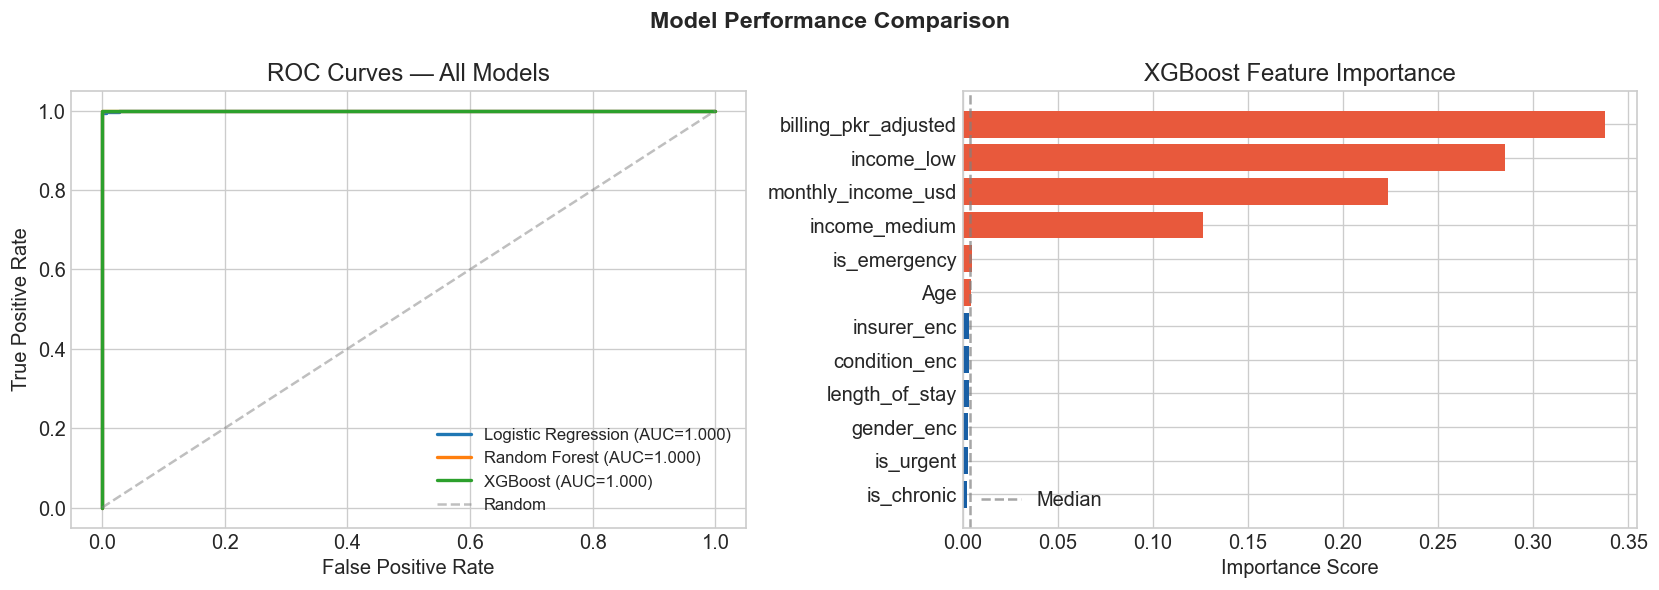

Saved: reports/figures/04_model_comparison.png ✓


In [19]:
# Cell 17 — Model Comparison + ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')

# ROC Curves
ax = axes[0]
for name, y_prob in [("Logistic Regression", y_prob_lr),
                      ("Random Forest",       y_prob_rf),
                      ("XGBoost",             y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=10)

# Feature Importance (XGBoost)
ax = axes[1]
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=True)
colors = ["#E8593C" if v > feat_imp.median() else "#185FA5" 
          for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors)
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance Score")
ax.axvline(feat_imp.median(), color='gray', 
           linestyle='--', alpha=0.7, label="Median")
ax.legend()

plt.tight_layout()
plt.savefig(FIG / "04_model_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: reports/figures/04_model_comparison.png ✓")

Calculating SHAP values (2-3 min lag sakta hai)...


C:\Users\Surface\AppData\Local\Temp\ipykernel_12552\2574676688.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test,


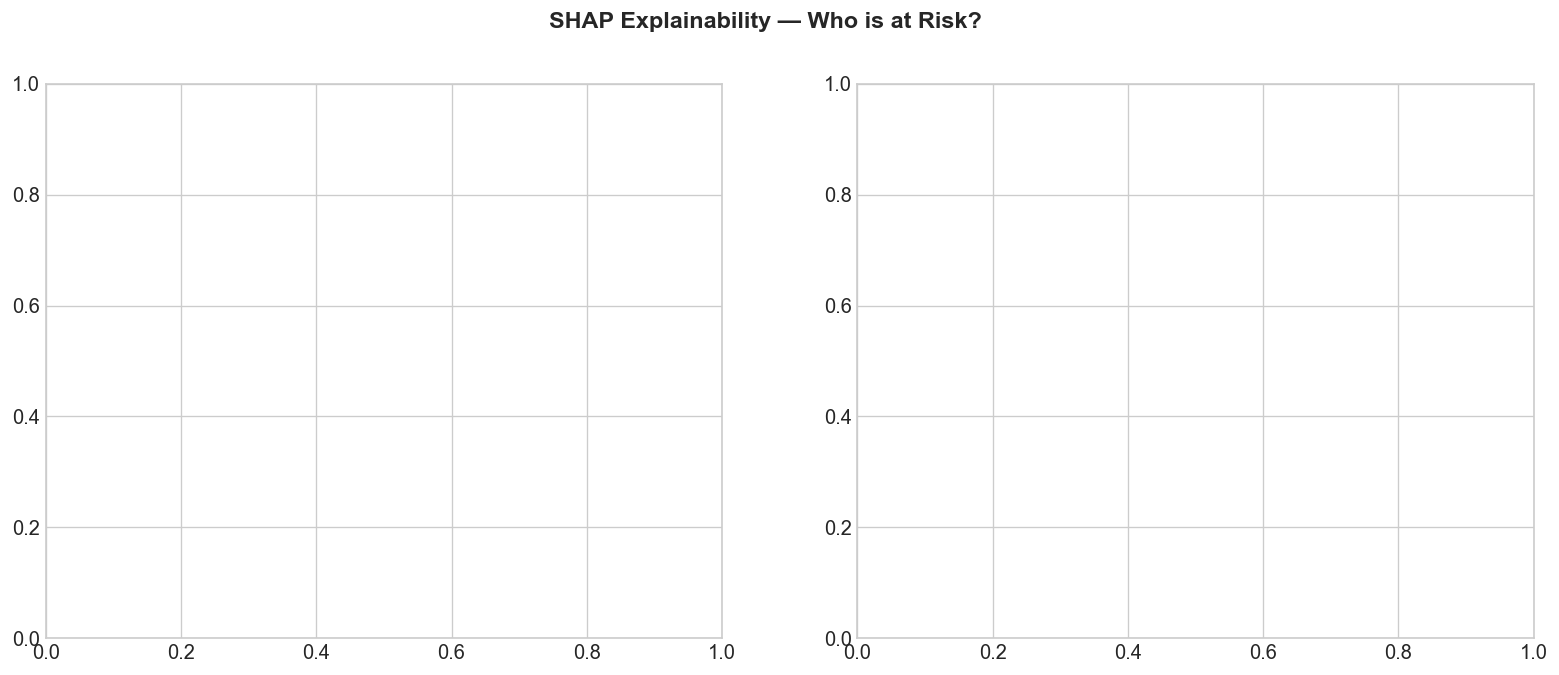

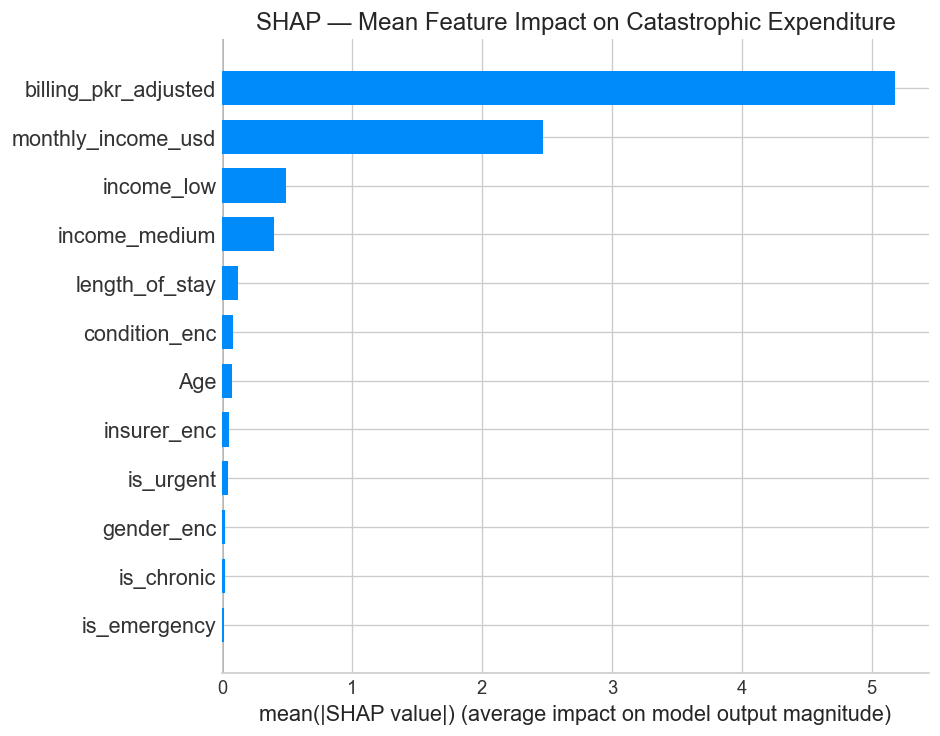

Saved: reports/figures/05_shap_summary.png ✓

TOP SHAP FINDINGS (paper ke liye):
  1. billing_pkr_adjusted      SHAP = 5.1801
  2. monthly_income_usd        SHAP = 2.4695
  3. income_low                SHAP = 0.4877
  4. income_medium             SHAP = 0.3972
  5. length_of_stay            SHAP = 0.1192


In [20]:
# Cell 18 — SHAP Analysis (paper ka crown)
import shap

print("Calculating SHAP values (2-3 min lag sakta hai)...")
explainer  = shap.TreeExplainer(xgb)
shap_vals  = explainer.shap_values(X_test)

# SHAP Summary Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("SHAP Explainability — Who is at Risk?", 
             fontsize=14, fontweight='bold')

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test, 
                  feature_names=FEATURES, 
                  show=False, plot_type="bar")
plt.title("SHAP — Mean Feature Impact on Catastrophic Expenditure")
plt.tight_layout()
plt.savefig(FIG / "05_shap_summary.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: reports/figures/05_shap_summary.png ✓")

# Top 3 SHAP findings
shap_df = pd.DataFrame(
    np.abs(shap_vals), columns=FEATURES
).mean().sort_values(ascending=False)

print("\n" + "="*50)
print("TOP SHAP FINDINGS (paper ke liye):")
print("="*50)
for i, (feat, val) in enumerate(shap_df.head(5).items(), 1):
    print(f"  {i}. {feat:<25} SHAP = {val:.4f}")

In [21]:
# Cell 19 — Data leakage fix
# billing_pkr_adjusted target banana mein use hua tha — remove karo

FEATURES_CLEAN = [
    "Age", "gender_enc", "condition_enc", "insurer_enc",
    "length_of_stay", "is_emergency", "is_urgent", "is_chronic",
    "monthly_income_usd", "income_low", "income_medium"
]

X2 = df[FEATURES_CLEAN]
y2 = df["is_catastrophic"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Rebalance
X2_tr = X2_train.copy(); X2_tr["target"] = y2_train.values
maj2 = X2_tr[X2_tr.target==1]
min2 = X2_tr[X2_tr.target==0]
maj2_dn = resample(maj2, n_samples=len(min2)*3, random_state=42, replace=False)
bal2 = pd.concat([maj2_dn, min2]).sample(frac=1, random_state=42)
X2_bal = bal2[FEATURES_CLEAN]; y2_bal = bal2["target"]

print(f"Clean features: {FEATURES_CLEAN}")
print(f"Train: {X2_train.shape[0]:,}  Test: {X2_test.shape[0]:,}")
print(f"Balanced: {len(X2_bal):,}")

Clean features: ['Age', 'gender_enc', 'condition_enc', 'insurer_enc', 'length_of_stay', 'is_emergency', 'is_urgent', 'is_chronic', 'monthly_income_usd', 'income_low', 'income_medium']
Train: 44,400  Test: 11,100
Balanced: 11,084


In [22]:
# Cell 20 — Retrain all models (clean)
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Logistic Regression
scaler2 = StandardScaler()
X2_bal_sc  = scaler2.fit_transform(X2_bal)
X2_test_sc = scaler2.transform(X2_test)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_bal_sc, y2_bal)
y2_pred_lr = lr2.predict(X2_test_sc)
y2_prob_lr = lr2.predict_proba(X2_test_sc)[:,1]

# Random Forest
rf2 = RandomForestClassifier(n_estimators=200, max_depth=10,
                              min_samples_leaf=5, random_state=42, n_jobs=-1)
rf2.fit(X2_bal, y2_bal)
y2_pred_rf = rf2.predict(X2_test)
y2_prob_rf = rf2.predict_proba(X2_test)[:,1]

# XGBoost
xgb2 = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      scale_pos_weight=3, eval_metric="auc",
                      random_state=42, n_jobs=-1)
xgb2.fit(X2_bal, y2_bal, eval_set=[(X2_test, y2_test)], verbose=False)
y2_pred_xgb = xgb2.predict(X2_test)
y2_prob_xgb = xgb2.predict_proba(X2_test)[:,1]

print("="*55)
print("RESULTS — LEAKAGE FREE")
print("="*55)
for name, pred, prob in [
    ("Logistic Regression", y2_pred_lr, y2_prob_lr),
    ("Random Forest",       y2_pred_rf, y2_prob_rf),
    ("XGBoost",             y2_pred_xgb, y2_prob_xgb),
]:
    auc = roc_auc_score(y2_test, prob)
    rep = classification_report(y2_test, pred,
          target_names=["Safe","Catastrophic"], output_dict=True)
    print(f"\n{name}")
    print(f"  AUC     : {auc:.4f}")
    print(f"  F1-Safe : {rep['Safe']['f1-score']:.4f}")
    print(f"  F1-Cat  : {rep['Catastrophic']['f1-score']:.4f}")
    print(f"  Accuracy: {rep['accuracy']:.4f}")

RESULTS — LEAKAGE FREE

Logistic Regression
  AUC     : 0.7992
  F1-Safe : 0.3285
  F1-Cat  : 0.9600
  Accuracy: 0.9245

Random Forest
  AUC     : 0.8028
  F1-Safe : 0.3262
  F1-Cat  : 0.9481
  Accuracy: 0.9036

XGBoost
  AUC     : 0.7954
  F1-Safe : 0.2755
  F1-Cat  : 0.9645
  Accuracy: 0.9323


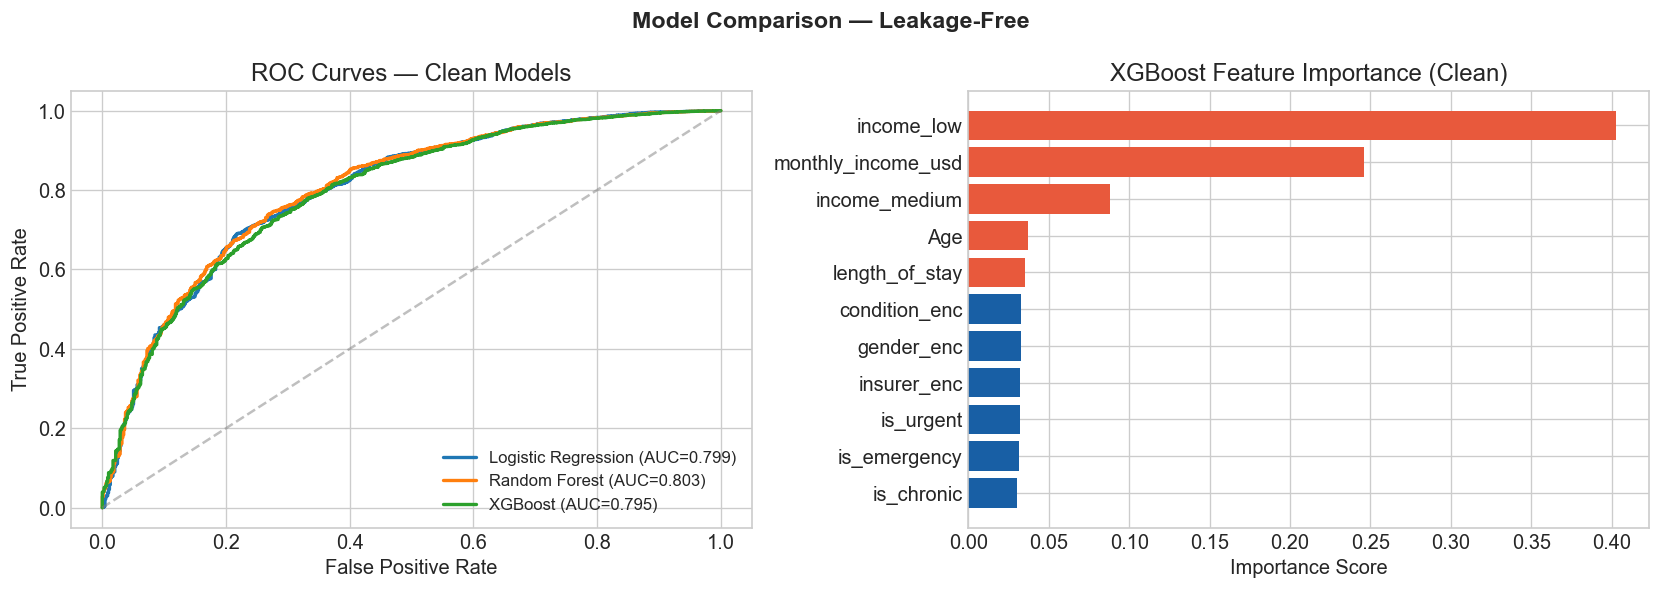

Saved ✓


In [23]:
# Cell 21 — Clean ROC + Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison — Leakage-Free", fontsize=14, fontweight='bold')

ax = axes[0]
for name, prob in [("Logistic Regression", y2_prob_lr),
                   ("Random Forest",       y2_prob_rf),
                   ("XGBoost",             y2_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y2_test, prob)
    auc = roc_auc_score(y2_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Clean Models")
ax.legend(fontsize=10)

ax = axes[1]
feat_imp2 = pd.Series(xgb2.feature_importances_,
                      index=FEATURES_CLEAN).sort_values(ascending=True)
colors2 = ["#E8593C" if v > feat_imp2.median() else "#185FA5"
           for v in feat_imp2.values]
ax.barh(feat_imp2.index, feat_imp2.values, color=colors2)
ax.set_title("XGBoost Feature Importance (Clean)")
ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(FIG / "06_clean_model_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ✓")

C:\Users\Surface\AppData\Local\Temp\ipykernel_12552\1645820675.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals2, X2_test,


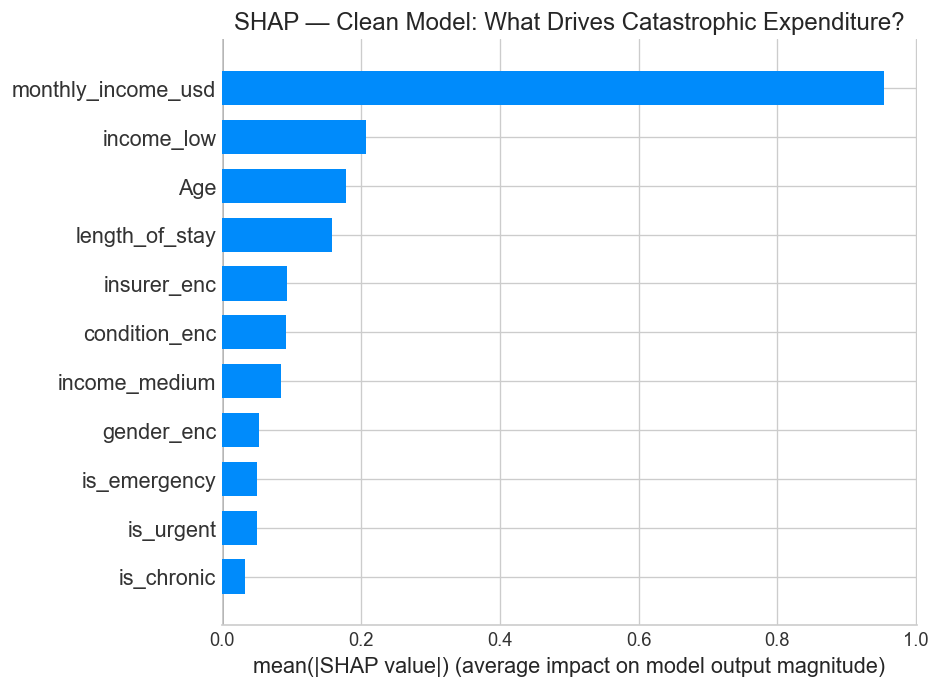


FINAL SHAP FINDINGS (paper ke liye):
  1. monthly_income_usd        SHAP = 0.9534
  2. income_low                SHAP = 0.2072
  3. Age                       SHAP = 0.1788
  4. length_of_stay            SHAP = 0.1580
  5. insurer_enc               SHAP = 0.0930


In [24]:
# Cell 22 — SHAP Clean
explainer2 = shap.TreeExplainer(xgb2)
shap_vals2 = explainer2.shap_values(X2_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals2, X2_test,
                  feature_names=FEATURES_CLEAN,
                  show=False, plot_type="bar")
plt.title("SHAP — Clean Model: What Drives Catastrophic Expenditure?")
plt.tight_layout()
plt.savefig(FIG / "07_shap_clean.png", bbox_inches='tight', dpi=150)
plt.show()

shap_df2 = pd.DataFrame(np.abs(shap_vals2),
                         columns=FEATURES_CLEAN).mean().sort_values(ascending=False)
print("\n" + "="*50)
print("FINAL SHAP FINDINGS (paper ke liye):")
print("="*50)
for i, (feat, val) in enumerate(shap_df2.head(5).items(), 1):
    print(f"  {i}. {feat:<25} SHAP = {val:.4f}")